# Small CNN Project

We will build, train, and evaluate a small convolutional neural network using PyTorch. 

Play or choose between **CIFAR‑10** (color) and **MNIST** (grayscale) datasets

**Task: Experiment with a design change (more filters, larger kernel, stride, padding, etc. ).**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

## Configuration
You can set the dataset and the design change you want to test below.

In [ ]:
# Choose dataset: 'cifar10' or 'mnist'
dataset_name = 'cifar10'

# Design change options: None, 'filters', 'kernel', 'stride'
design_change = None  # e.g., 'filters'

# Hyper‑parameters
batch_size = 64
learning_rate = 1e-3
num_epochs = 10

## Data Loading

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) if dataset_name == 'mnist' else transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

if dataset_name == 'cifar10':
    train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    num_classes = 10
    in_channels = 3
else:
    train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    num_classes = 10
    in_channels = 1

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

100%|██████████| 170498071/170498071 [21:33<00:00, 131770.16it/s]


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified


## Model Definition
The architecture follows three Conv + ReLU + MaxPool blocks and a fully‑connected head.

In [ ]:
class SmallCNN(nn.Module):
    def __init__(self, in_channels, num_classes, change=None):
        super(SmallCNN, self).__init__()

        # Default hyper‑parameters
        conv1_out = 16
        conv2_out = 32
        conv3_out = 64
        kernel = 3
        stride = 1
        padding = 1

        # Apply design change if requested
        if change == 'filters':
            conv1_out = 32  # increase first layer filters
        elif change == 'kernel':
            kernel = 5
            padding = 2
        elif change == 'stride':
            stride = 2

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, conv1_out, kernel_size=kernel, stride=stride, padding=padding),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(conv1_out, conv2_out, kernel_size=kernel, stride=1, padding=padding),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(conv2_out, conv3_out, kernel_size=kernel, stride=1, padding=padding),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Compute the size of the feature map after conv blocks
        self._feature_size = self._calc_feature_size()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._feature_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def _calc_feature_size(self):
        # Dummy forward pass with a single sample to infer shape
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 32, 32) if in_channels == 3 else torch.zeros(1, 1, 28, 28)
            x = self.block1(dummy)
            x = self.block2(x)
            x = self.block3(x)
            return x.numel()
            
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

## Helper Functions

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

## Training Loop

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SmallCNN(in_channels, num_classes, change=design_change).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
best_val_acc = 0.0
best_model_path = 'best_cnn.pth'

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    print(f'Epoch {epoch}/{num_epochs} – Train loss: {train_loss:.4f}, acc: {train_acc:.4f} – Val loss: {val_loss:.4f}, acc: {val_acc:.4f}')
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

print('Training complete. Best validation accuracy:', best_val_acc)
# Parameter count
total_params = sum(p.numel() for p in model.parameters())
print('Total parameters:', total_params)

Epoch 1/10 – Train loss: 1.4918, acc: 0.4571 – Val loss: 1.2385, acc: 0.5543
Epoch 2/10 – Train loss: 1.1239, acc: 0.6016 – Val loss: 1.0376, acc: 0.6298
Epoch 3/10 – Train loss: 0.9529, acc: 0.6628 – Val loss: 0.9339, acc: 0.6738
Epoch 4/10 – Train loss: 0.8330, acc: 0.7064 – Val loss: 0.8655, acc: 0.7029
Epoch 5/10 – Train loss: 0.7474, acc: 0.7388 – Val loss: 0.8343, acc: 0.7115
Epoch 6/10 – Train loss: 0.6808, acc: 0.7618 – Val loss: 0.8223, acc: 0.7183
Epoch 7/10 – Train loss: 0.6214, acc: 0.7822 – Val loss: 0.8101, acc: 0.7188
Epoch 8/10 – Train loss: 0.5657, acc: 0.8025 – Val loss: 0.8091, acc: 0.7291
Epoch 9/10 – Train loss: 0.5177, acc: 0.8196 – Val loss: 0.8103, acc: 0.7310
Epoch 10/10 – Train loss: 0.4786, acc: 0.8319 – Val loss: 0.8597, acc: 0.7184
Training complete. Best validation accuracy: 0.731
Total parameters: 156074


## Plotting Results

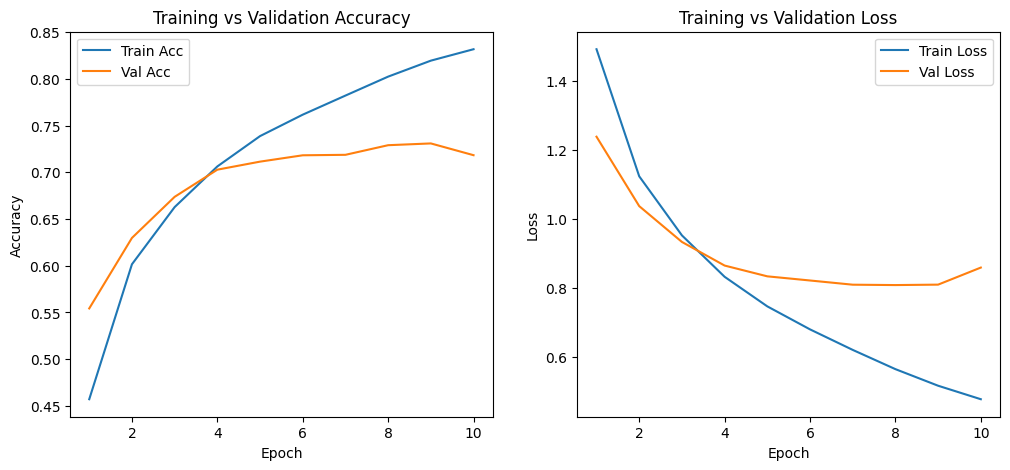

In [8]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(1, num_epochs+1), train_accuracies, label='Train Acc')
plt.plot(range(1, num_epochs+1), val_accuracies, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()